## 3.2 Max-Cut 문제

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import transpile
import networkx as nx
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_optimization.applications import Maxcut
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

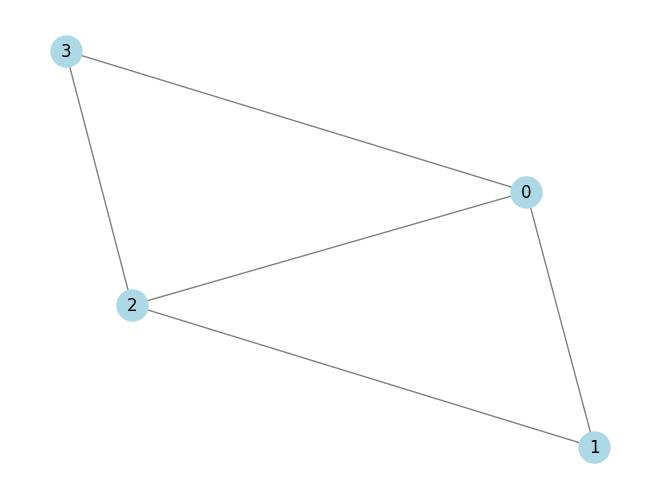

In [2]:
# Max-Cut 문제를 위한 그래프 정의
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)])
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
plt.show()

In [3]:
# 그래프의 가중치 행렬 얻기
w = nx.adjacency_matrix(G).todense()

In [4]:
# QAOA 파라미터 정의
num_qubits = len(G.nodes)
p = 1  # QAOA 층 수
beta = Parameter('β')
gamma = Parameter('γ')

In [5]:
# QAOA 회로 생성
qaoa_circuit = QuantumCircuit(num_qubits)

In [6]:
# 중첩으로 초기화
for i in range(num_qubits):
    qaoa_circuit.h(i)

In [7]:
# 문제 유니터리
for u, v in G.edges:
    qaoa_circuit.cx(u, v)
    qaoa_circuit.rz(2 * gamma, v)
    qaoa_circuit.cx(u, v)

In [8]:
# 믹서 유니터리
for i in range(num_qubits):
    qaoa_circuit.rx(2 * beta, i)

In [9]:
# 큐비트 측정
qaoa_circuit.measure_all()

In [10]:
# assign_parameters 로 파라미터 바인딩
param_values = {beta: np.pi/4, gamma: np.pi/4}
bound_circuit = qaoa_circuit.assign_parameters(param_values)

In [11]:
# 시뮬레이터용으로 회로 트랜스파일
simulator = AerSimulator()
compiled_circuit = transpile(bound_circuit, simulator)

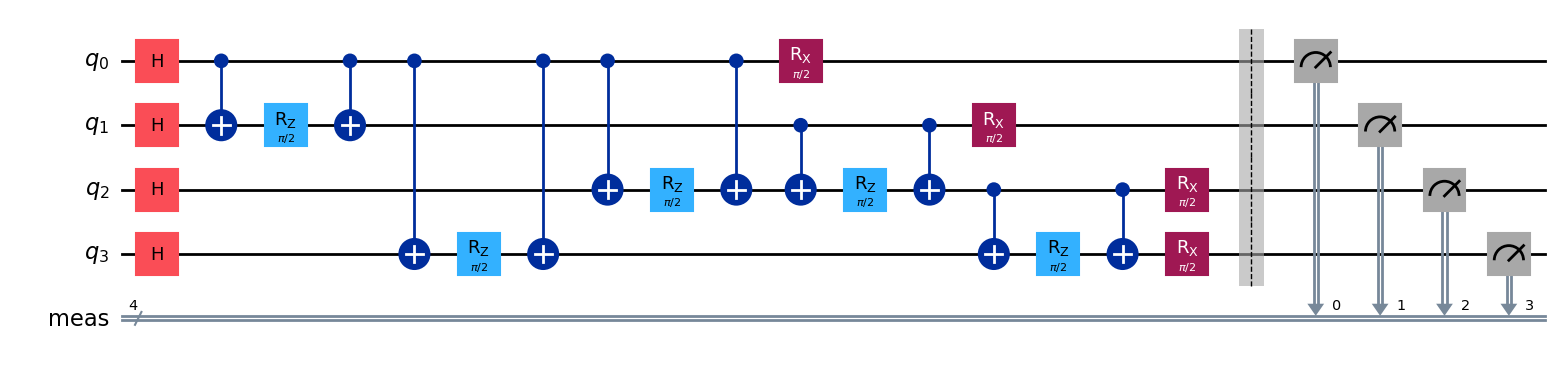

In [12]:
# 회로 시각화
bound_circuit.draw('mpl')
plt.show()

In [13]:
# 회로 시뮬레이션
result = simulator.run(compiled_circuit, shots=1000).result()
counts = result.get_counts()

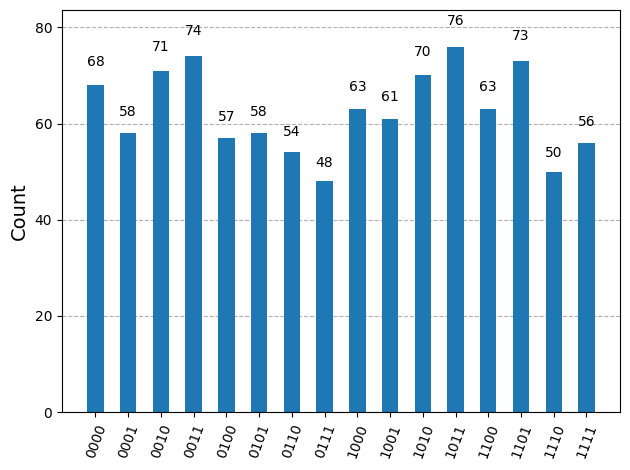

In [14]:
# 결과 그리기
plot_histogram(counts)
plt.show()

In [15]:
# 결과 해석
bitstrings = list(counts.keys())
max_cut_value = -np.inf
max_cut_solution = None

In [16]:
# 절단값 평가를 위해 Maxcut 클래스 사용
maxcut = Maxcut(w)
qp = maxcut.to_quadratic_program()

In [17]:
# 절단값을 계산하는 보조 함수
def compute_cut_value(bitstring, qp, num_nodes):
    binary_array = np.array([int(bit) for bit in bitstring])
    value = qp.objective.evaluate(binary_array)
    return value

In [18]:
# 각 비트열을 평가해 최적 해 찾기
for bitstring in bitstrings:
    cut_value = compute_cut_value(bitstring, qp, num_qubits)
    if cut_value > max_cut_value:
        max_cut_value = cut_value
        max_cut_solution = bitstring

In [19]:
# 최적 절단값과 해 출력
print("Optimal cut value:", max_cut_value)
print("Optimal cut solution:", max_cut_solution)

Optimal cut value: 4.0
Optimal cut solution: 0101


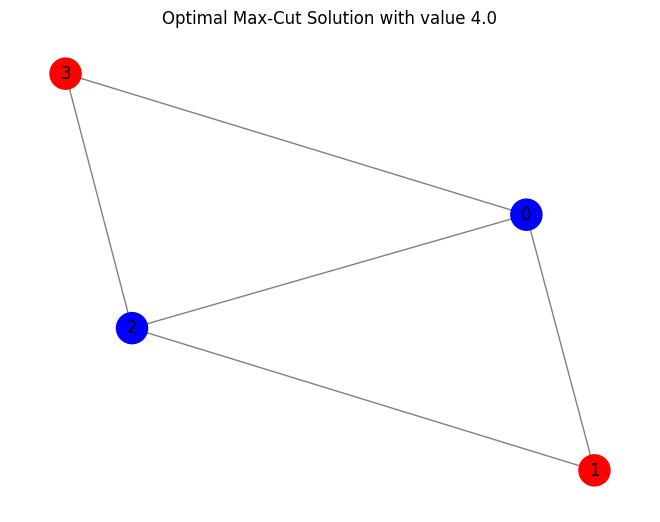

In [20]:
# 최적 해 시각화
colors = ['red' if bit == '1' else 'blue' for bit in max_cut_solution]
nx.draw(G, pos, with_labels=True, node_color=colors, edge_color='gray', node_size=500)
plt.title(f"Optimal Max-Cut Solution with value {max_cut_value}")
plt.show()